In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print(matches.shape)
print(deliveries.shape)

matches.head()


(1095, 20)
(260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
print(matches.columns)
print(deliveries.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='str')
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


In [5]:
matches.isnull().sum()


id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [6]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [7]:
top_batters = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False)

top_batters.head(10)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

In [8]:
top_bowlers = deliveries['bowler'].value_counts()

top_bowlers.head(10)

bowler
R Ashwin           4679
SP Narine          4146
B Kumar            4060
PP Chawla          3895
RA Jadeja          3895
YS Chahal          3628
Harbhajan Singh    3496
A Mishra           3444
DJ Bravo           3296
UT Yadav           3190
Name: count, dtype: int64

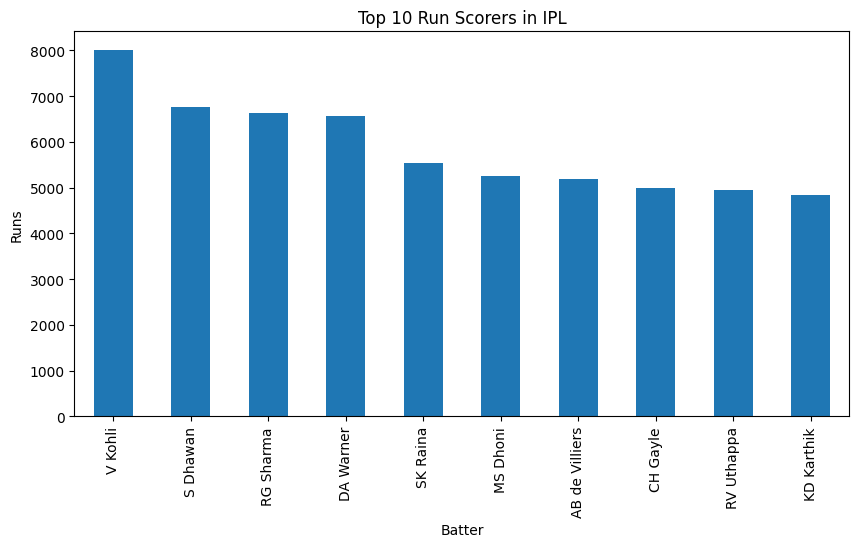

In [9]:
top_batters = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_batters.plot(kind='bar')

plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batter")
plt.ylabel("Runs")
plt.show()

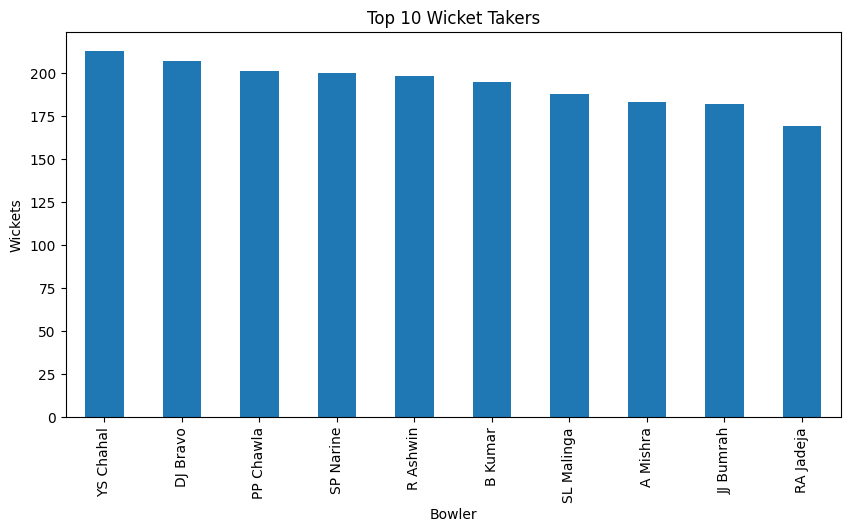

In [10]:
top_wickets = deliveries.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_wickets.plot(kind='bar')

plt.title("Top 10 Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.show()

In [11]:
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [12]:
batter_name = "V Kohli"
deliveries['batter'].unique()
deliveries[deliveries['batter'].str.contains('Kohli', case=False, na=False)]['batter'].unique()

<StringArray>
['V Kohli', 'T Kohli']
Length: 2, dtype: str

In [13]:
batter_name = "V Kohli"

batter_data = deliveries[deliveries['batter'] == batter_name]

total_runs = batter_data['batsman_runs'].sum()
balls_faced = len(batter_data)

strike_rate = (total_runs / balls_faced) * 100

dismissals = batter_data['is_wicket'].sum()

print("Runs:", total_runs)
print("Balls Faced:", balls_faced)
print("Strike Rate:", round(strike_rate,2))
print("Dismissals:", dismissals)

Runs: 8014
Balls Faced: 6236
Strike Rate: 128.51
Dismissals: 218


In [14]:
powerplay = batter_data[batter_data['over'] <= 6]
middle = batter_data[(batter_data['over'] > 6) & (batter_data['over'] <= 15)]
death = batter_data[batter_data['over'] > 15]

print("Powerplay Runs:", powerplay['batsman_runs'].sum())
print("Middle Overs Runs:", middle['batsman_runs'].sum())
print("Death Overs Runs:", death['batsman_runs'].sum())

Powerplay Runs: 3178
Middle Overs Runs: 3737
Death Overs Runs: 1099


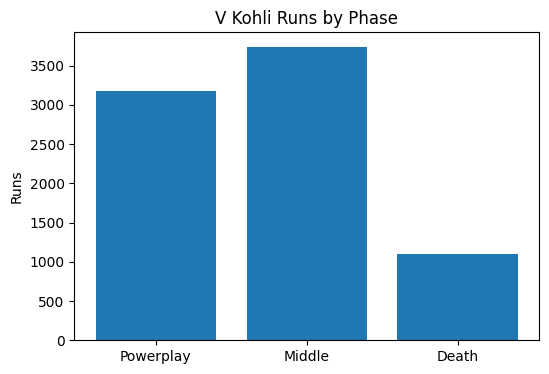

In [15]:
phase_runs = {
    'Powerplay': powerplay['batsman_runs'].sum(),
    'Middle': middle['batsman_runs'].sum(),
    'Death': death['batsman_runs'].sum()
}

plt.figure(figsize=(6,4))
plt.bar(phase_runs.keys(), phase_runs.values())
plt.title(f"{batter_name} Runs by Phase")
plt.ylabel("Runs")
plt.show()

In [16]:
dismissals = batter_data[batter_data['is_wicket'] == 1]

dismissed_by = dismissals['bowler'].value_counts().head(10)

print(dismissed_by)

bowler
Sandeep Sharma    7
A Nehra           6
RA Jadeja         5
UT Yadav          5
JJ Bumrah         5
B Kumar           5
Mohammed Shami    5
IK Pathan         4
Z Khan            4
DS Kulkarni       4
Name: count, dtype: int64


In [17]:
top_bowler = dismissed_by.index[0]

print(f"{batter_name} is most frequently dismissed by {top_bowler}")

V Kohli is most frequently dismissed by Sandeep Sharma


In [18]:
phase_stats = []

for phase_name, phase_data in {
    "Powerplay": powerplay,
    "Middle": middle,
    "Death": death
}.items():

    runs = phase_data['batsman_runs'].sum()
    balls = len(phase_data)

    sr = (runs / balls) * 100

    phase_stats.append([phase_name, runs, balls, round(sr,2)])

for row in phase_stats:
    print(row)

['Powerplay', np.int64(3178), 2735, np.float64(116.2)]
['Middle', np.int64(3737), 2930, np.float64(127.54)]
['Death', np.int64(1099), 571, np.float64(192.47)]


In [19]:
def batter_analyzer(batter_name):

    batter_data = deliveries[deliveries['batter'] == batter_name]

    runs = batter_data['batsman_runs'].sum()
    balls = len(batter_data)

    sr = (runs / balls) * 100

    dismissals = batter_data['is_wicket'].sum()

    print("Player:", batter_name)
    print("Runs:", runs)
    print("Balls:", balls)
    print("Strike Rate:", round(sr,2))
    print("Dismissals:", dismissals)

In [20]:
batter_analyzer("V Kohli")
batter_analyzer("RG Sharma")
batter_analyzer("MS Dhoni")
batter_analyzer("S Dhawan")

Player: V Kohli
Runs: 8014
Balls: 6236
Strike Rate: 128.51
Dismissals: 218
Player: RG Sharma
Runs: 6630
Balls: 5183
Strike Rate: 127.92
Dismissals: 232
Player: MS Dhoni
Runs: 5243
Balls: 3947
Strike Rate: 132.84
Dismissals: 149
Player: S Dhawan
Runs: 6769
Balls: 5483
Strike Rate: 123.45
Dismissals: 194


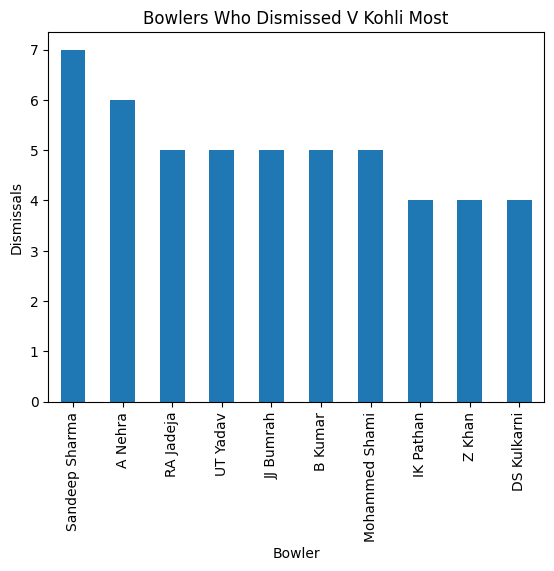

In [21]:
dismissed_by.plot(kind='bar')

plt.title("Bowlers Who Dismissed V Kohli Most")
plt.xlabel("Bowler")
plt.ylabel("Dismissals")
plt.show()

In [22]:
def batter_vs_bowler(batter_name, bowler_name):

    data = deliveries[
        (deliveries['batter'] == batter_name) &
        (deliveries['bowler'] == bowler_name)
    ]

    runs = data['batsman_runs'].sum()
    balls = len(data)

    strike_rate = (runs / balls) * 100 if balls > 0 else 0

    dismissals = data['is_wicket'].sum()

    fours = len(data[data['batsman_runs'] == 4])
    sixes = len(data[data['batsman_runs'] == 6])

    print("Batter:", batter_name)
    print("Bowler:", bowler_name)
    print("Runs:", runs)
    print("Balls:", balls)
    print("Strike Rate:", round(strike_rate,2))
    print("Dismissals:", dismissals)
    print("Fours:", fours)
    print("Sixes:", sixes)

In [23]:
batter_vs_bowler("V Kohli","JJ Bumrah")

batter_vs_bowler("V Kohli","RA Jadeja")

Batter: V Kohli
Bowler: JJ Bumrah
Runs: 145
Balls: 98
Strike Rate: 147.96
Dismissals: 5
Fours: 16
Sixes: 5
Batter: V Kohli
Bowler: RA Jadeja
Runs: 157
Balls: 148
Strike Rate: 106.08
Dismissals: 5
Fours: 8
Sixes: 4


In [24]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [25]:
print(matches.columns.tolist())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [26]:
matches['team1_win'] = (matches['winner'] == matches['team1']).astype(int)

matches[['team1','winner','team1_win']].head()

,team1,winner,team1_win
0,Royal Challengers Bangalore,Kolkata Knight Riders,0
1,Kings XI Punjab,Chennai Super Kings,0
2,Delhi Daredevils,Delhi Daredevils,1
3,Mumbai Indians,Royal Challengers Bangalore,0
4,Kolkata Knight Riders,Kolkata Knight Riders,1


In [27]:
features = matches[['target_runs','target_overs']]
target = matches['team1_win']

In [28]:
features = features.fillna(0)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 53.42 %


In [32]:
new_match = [[180,20]]

probability = model.predict_proba(new_match)

print(probability)

[[0.78801162 0.21198838]]


C:\Users\princ\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [33]:
matches.shape

(1095, 21)

In [34]:
matches[['team1','team2','winner']].head()

,team1,team2,winner
0,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings
2,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils
3,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore
4,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders


In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

matches['team1'] = le.fit_transform(matches['team1'])
matches['team2'] = le.fit_transform(matches['team2'])
matches['city'] = le.fit_transform(matches['city'].astype(str))
matches['toss_winner'] = le.fit_transform(matches['toss_winner'].astype(str))
matches['toss_decision'] = le.fit_transform(matches['toss_decision'].astype(str))

In [36]:
features = matches[
    ['team1',
     'team2',
     'city',
     'toss_winner',
     'toss_decision',
     'target_runs',
     'target_overs']
]

target = matches['team1_win']

In [37]:
features = features.fillna(0)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 59.36 %


In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[63 35]
 [54 67]]


In [43]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

         Feature  Importance
5    target_runs    0.344211
2           city    0.170971
1          team2    0.157104
0          team1    0.139412
3    toss_winner    0.134920
4  toss_decision    0.038359
6   target_overs    0.015023


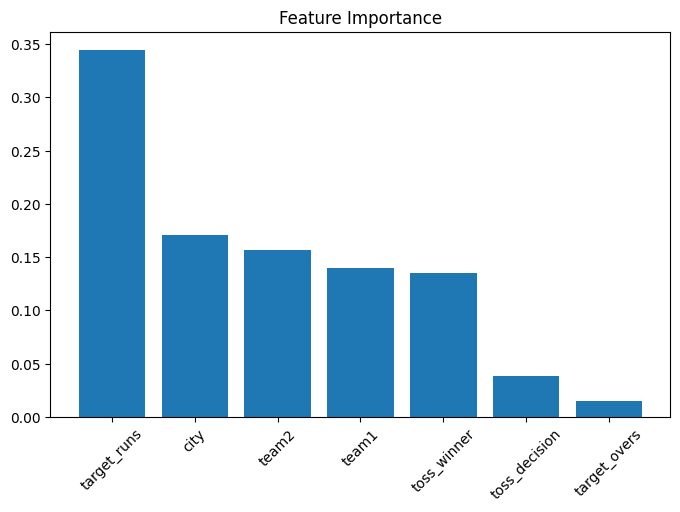

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.xticks(rotation=45)

plt.show()

In [45]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [46]:
deliveries.shape

(260920, 17)

In [47]:
score_df = deliveries.groupby(['match_id','inning']).agg({
    'total_runs':'sum',
    'is_wicket':'sum'
}).reset_index()

score_df.head()

,match_id,inning,total_runs,is_wicket
0,335982,1,222,3
1,335982,2,82,10
2,335983,1,240,5
3,335983,2,207,4
4,335984,1,129,8


In [48]:
deliveries['ball_number'] = deliveries['over']*6 + deliveries['ball']
deliveries[['over','ball','ball_number']].head()

,over,ball,ball_number
0,0,1,1
1,0,2,2
2,0,3,3
3,0,4,4
4,0,5,5


In [49]:
deliveries['current_score'] = deliveries.groupby(
    ['match_id','inning']
)['total_runs'].cumsum()

In [50]:
deliveries[
    ['match_id','over','ball','total_runs','current_score']
].head(15)

,match_id,over,ball,total_runs,current_score
0,335982,0,1,1,1
1,335982,0,2,0,1
2,335982,0,3,1,2
3,335982,0,4,0,2
4,335982,0,5,0,2
5,335982,0,6,0,2
6,335982,0,7,1,3
7,335982,1,1,0,3
8,335982,1,2,4,7
9,335982,1,3,4,11


In [51]:
deliveries['current_wickets'] = deliveries.groupby(
    ['match_id','inning']
)['is_wicket'].cumsum()
deliveries[
    ['match_id','over','ball','current_wickets']
].head(15)

,match_id,over,ball,current_wickets
0,335982,0,1,0
1,335982,0,2,0
2,335982,0,3,0
3,335982,0,4,0
4,335982,0,5,0
5,335982,0,6,0
6,335982,0,7,0
7,335982,1,1,0
8,335982,1,2,0
9,335982,1,3,0


In [52]:
deliveries['balls_remaining'] = 120 - deliveries['ball_number']
deliveries['wickets_remaining'] = 10 - deliveries['current_wickets']

In [53]:
deliveries['current_rr'] = (
    deliveries['current_score'] * 6
) / deliveries['ball_number']

In [54]:
deliveries[[
    'current_score',
    'current_wickets',
    'balls_remaining',
    'wickets_remaining',
    'current_rr'
]].head()

,current_score,current_wickets,balls_remaining,wickets_remaining,current_rr
0,1,0,119,10,6.0
1,1,0,118,10,3.0
2,2,0,117,10,4.0
3,2,0,116,10,3.0
4,2,0,115,10,2.4


In [55]:
match_winners = matches[['id','winner']]
match_winners.head()

,id,winner
0,335982,Kolkata Knight Riders
1,335983,Chennai Super Kings
2,335984,Delhi Daredevils
3,335985,Royal Challengers Bangalore
4,335986,Kolkata Knight Riders


In [56]:
match_winners = match_winners.rename(columns={'id':'match_id'})

In [57]:
deliveries = deliveries.merge(
    match_winners,
    on='match_id',
    how='left'
)

In [58]:
deliveries[['match_id','batting_team','winner']].head()

,match_id,batting_team,winner
0,335982,Kolkata Knight Riders,Kolkata Knight Riders
1,335982,Kolkata Knight Riders,Kolkata Knight Riders
2,335982,Kolkata Knight Riders,Kolkata Knight Riders
3,335982,Kolkata Knight Riders,Kolkata Knight Riders
4,335982,Kolkata Knight Riders,Kolkata Knight Riders


In [59]:
deliveries['result'] = (
    deliveries['batting_team'] == deliveries['winner']
).astype(int)

In [60]:
features = deliveries[
    [
        'current_score',
        'current_wickets',
        'balls_remaining',
        'wickets_remaining',
        'current_rr'
    ]
]

target = deliveries['result']

In [61]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [67]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [68]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print(
    "Accuracy:",
    round(
        accuracy_score(y_test,pred)*100,
        2
    ),
    "%"
)

Accuracy: 59.77 %


In [69]:
matches.columns.tolist()

['id',
 'season',
 'city',
 'date',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'result_margin',
 'target_runs',
 'target_overs',
 'super_over',
 'method',
 'umpire1',
 'umpire2',
 'team1_win']

In [70]:
player_stats = deliveries.groupby('batter').agg({
    'batsman_runs':'sum',
    'ball':'count',
    'is_wicket':'sum'
}).reset_index()

player_stats.head()

,batter,batsman_runs,ball,is_wicket
0,A Ashish Reddy,280,196,15
1,A Badoni,634,505,26
2,A Chandila,4,7,1
3,A Chopra,53,75,5
4,A Choudhary,25,20,2


In [71]:
player_stats.columns = [
    'player',
    'runs',
    'balls_faced',
    'dismissals'
]

player_stats.head()

,player,runs,balls_faced,dismissals
0,A Ashish Reddy,280,196,15
1,A Badoni,634,505,26
2,A Chandila,4,7,1
3,A Chopra,53,75,5
4,A Choudhary,25,20,2


In [72]:
player_stats['strike_rate'] = (
    player_stats['runs']
    /
    player_stats['balls_faced']
) * 100

In [73]:
player_stats['fantasy_points'] = (
    player_stats['runs']*1
    +
    player_stats['strike_rate']*0.2
    -
    player_stats['dismissals']*0.5
)

In [74]:
player_stats.sort_values(
    'fantasy_points',
    ascending=False
).head(20)

,player,runs,balls_faced,dismissals,strike_rate,fantasy_points
631,V Kohli,8014,6236,218,128.511867,7930.702373
512,S Dhawan,6769,5483,194,123.454313,6696.690863
477,RG Sharma,6630,5183,232,127.918194,6539.583639
147,DA Warner,6567,4849,164,135.429986,6512.085997
546,SK Raina,5536,4177,168,132.535312,5478.507062
374,MS Dhoni,5243,3947,149,132.835065,5195.067013
30,AB de Villiers,5181,3487,125,148.580442,5148.216088
124,CH Gayle,4997,3516,128,142.121729,4961.424346
501,RV Uthappa,4954,3927,184,126.152279,4887.230456
282,KD Karthik,4843,3687,189,131.353404,4774.770681


In [75]:
X = player_stats[
    [
        'runs',
        'balls_faced',
        'strike_rate',
        'dismissals'
    ]
]

y = player_stats['fantasy_points']

In [76]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [77]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [78]:
player_stats['predicted_points'] = model.predict(X)

In [79]:
player_stats.sort_values(
    'predicted_points',
    ascending=False
)[
    ['player','predicted_points']
].head(11)

,player,predicted_points
512,S Dhawan,6526.237322
631,V Kohli,6513.040926
477,RG Sharma,6490.305412
147,DA Warner,6196.101046
546,SK Raina,5310.935148
374,MS Dhoni,5087.848739
501,RV Uthappa,5036.237964
282,KD Karthik,4902.385311
30,AB de Villiers,4893.004818
124,CH Gayle,4830.142217


In [80]:
best_xi = player_stats.sort_values(
    'predicted_points',
    ascending=False
).head(11)

best_xi[['player','predicted_points']]

,player,predicted_points
512,S Dhawan,6526.237322
631,V Kohli,6513.040926
477,RG Sharma,6490.305412
147,DA Warner,6196.101046
546,SK Raina,5310.935148
374,MS Dhoni,5087.848739
501,RV Uthappa,5036.237964
282,KD Karthik,4902.385311
30,AB de Villiers,4893.004818
124,CH Gayle,4830.142217


In [81]:
best_xi[['player','predicted_points']]

,player,predicted_points
512,S Dhawan,6526.237322
631,V Kohli,6513.040926
477,RG Sharma,6490.305412
147,DA Warner,6196.101046
546,SK Raina,5310.935148
374,MS Dhoni,5087.848739
501,RV Uthappa,5036.237964
282,KD Karthik,4902.385311
30,AB de Villiers,4893.004818
124,CH Gayle,4830.142217


In [82]:
top_recent = deliveries.groupby('batter').agg({
    'batsman_runs':'mean'
}).reset_index()

top_recent.columns = [
    'player',
    'avg_runs_per_ball'
]

top_recent.sort_values(
    'avg_runs_per_ball',
    ascending=False
).head()

,player,avg_runs_per_ball
312,L Wood,3.000000
97,B Stanlake,2.500000
234,J Fraser-McGurk,2.200000
461,R Sai Kishore,2.166667
629,Umar Gul,2.052632


In [83]:
best_xi = player_stats.sort_values(
    'predicted_points',
    ascending=False
).head(11)

captain = best_xi.iloc[0]['player']
vice_captain = best_xi.iloc[1]['player']

print("Captain:", captain)
print("Vice Captain:", vice_captain)

Captain: S Dhawan
Vice Captain: V Kohli
